<a href="https://colab.research.google.com/github/pin-chien135/Ocean_current/blob/main/monthly_current_land_mask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install cartopy netcdf4 xarray -q
!apt-get install ffmpeg -y -q


Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [19]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.interpolate import griddata
from datetime import datetime


In [20]:
# 路徑
DATA_DIR = "/content/"
files = sorted(
    glob.glob(
        os.path.join(
            DATA_DIR,
            "TOTL_TORO_2016_01_*.tuv" ###檔名###
        )
    )
)

print("檔案數量:", len(files))

檔案數量: 744


In [21]:
# 讀取tuv
def read_tuv(filename):

    with open(filename, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if "%TableStart:" in line:
            start = i + 3
            break

    cols = [
        "LOND",
        "LATD",
        "VELU",
        "VELV",
        "VFLG",
        "UQAL",
        "VQAL",
        "CQAL",
        "XDST",
        "YDST",
        "RNGE",
        "BEAR",
        "VELO",
        "HEAD"
    ]

    df = pd.read_csv(
        filename,
        skiprows=start,
        sep=r"\s+",
        names=cols,
        usecols=range(14),
        engine="python",
        on_bad_lines="skip"
    )

    return df

In [22]:
# 從檔名取時間
def get_time(filename):

    name = os.path.basename(filename)
    parts = name.replace(".tuv","").split("_")

    year = int(parts[2])
    month = int(parts[3])
    day = int(parts[4])
    hour = int(parts[5][:2])


    return datetime(
        year,
        month,
        day,
        hour
    )

In [23]:
# 讀取每小時資料
all_data=[]

for f in files:
    print("讀取",os.path.basename(f))
    df = read_tuv(f)

    # 加時間
    df["time"] = get_time(f)
    all_data.append(df)

data = pd.concat(
    all_data,
    ignore_index=True
)


讀取 TOTL_TORO_2016_01_01_0000.tuv
讀取 TOTL_TORO_2016_01_01_0100.tuv
讀取 TOTL_TORO_2016_01_01_0200.tuv
讀取 TOTL_TORO_2016_01_01_0300.tuv
讀取 TOTL_TORO_2016_01_01_0400.tuv
讀取 TOTL_TORO_2016_01_01_0500.tuv
讀取 TOTL_TORO_2016_01_01_0600.tuv
讀取 TOTL_TORO_2016_01_01_0700.tuv
讀取 TOTL_TORO_2016_01_01_0800.tuv
讀取 TOTL_TORO_2016_01_01_0900.tuv
讀取 TOTL_TORO_2016_01_01_1000.tuv
讀取 TOTL_TORO_2016_01_01_1100.tuv
讀取 TOTL_TORO_2016_01_01_1200.tuv
讀取 TOTL_TORO_2016_01_01_1300.tuv
讀取 TOTL_TORO_2016_01_01_1400.tuv
讀取 TOTL_TORO_2016_01_01_1500.tuv
讀取 TOTL_TORO_2016_01_01_1600.tuv
讀取 TOTL_TORO_2016_01_01_1700.tuv
讀取 TOTL_TORO_2016_01_01_1800.tuv
讀取 TOTL_TORO_2016_01_01_1900.tuv
讀取 TOTL_TORO_2016_01_01_2000.tuv
讀取 TOTL_TORO_2016_01_01_2100.tuv
讀取 TOTL_TORO_2016_01_01_2200.tuv
讀取 TOTL_TORO_2016_01_01_2300.tuv
讀取 TOTL_TORO_2016_01_02_0000.tuv
讀取 TOTL_TORO_2016_01_02_0100.tuv
讀取 TOTL_TORO_2016_01_02_0200.tuv
讀取 TOTL_TORO_2016_01_02_0300.tuv
讀取 TOTL_TORO_2016_01_02_0400.tuv
讀取 TOTL_TORO_2016_01_02_0500.tuv
讀取 TOTL_TO

In [24]:
# 建立日期
data["date"] = data["time"].dt.date

In [25]:
# 測試
#data[data["VELU"].astype(str).str.contains("BABY")].head()

In [26]:
# 轉數值
data = pd.concat(
    all_data,
    ignore_index=True
)
for c in ["LOND","LATD","VELU","VELV","VFLG"]:

    data[c] = pd.to_numeric(
        data[c],
        errors="coerce"
    )

data = data.dropna(
    subset=[
        "LOND",
        "LATD",
        "VELU",
        "VELV"
    ]
)

In [27]:
# QC
data = data[
    data["VFLG"] == 0
]
#print(data.dtypes)

In [28]:
# 日平均
daily = (
    data
    .groupby(
        [
            #"date",
            "LOND",
            "LATD"
        ]
    )
    [["VELU","VELV"]]
    .mean()
    .reset_index()
)

In [29]:
# 月平均
monthly = (
    daily
    .groupby(
        [
            "LOND",
            "LATD"
        ]
    )
    [["VELU","VELV"]]
    .mean()
    .reset_index()
)


print(monthly.shape)

(1637, 4)


In [30]:
# 流速
monthly["Speed"] = np.sqrt(
    monthly["VELU"]**2 +
    monthly["VELV"]**2
)
# 定義
lon = monthly["LOND"].values
lat = monthly["LATD"].values

u = monthly["VELU"].values
v = monthly["VELV"].values
speed = monthly["Speed"].values

In [31]:
# 建立規則網格
lon_grid = np.linspace(
    lon.min(),
    lon.max(),
    150
)
lat_grid = np.linspace(
    lat.min(),
    lat.max(),
    150
)
Lon,Lat = np.meshgrid(
    lon_grid,
    lat_grid
)



# 插值
U_grid = griddata(
    (lon,lat),
    u,
    (Lon,Lat),
    method="linear"
)

V_grid = griddata(
    (lon,lat),
    v,
    (Lon,Lat),
    method="linear"
)


Speed_grid = np.sqrt(
    U_grid**2+
    V_grid**2
)

In [32]:
# 建立 Land Mask
land_shp = shpreader.natural_earth(
    resolution="10m",
    category="physical",
    name="land"
)
reader = shpreader.Reader(land_shp)

# 合併所有陸地
land = unary_union(list(reader.geometries()))
print("建立Land Polygon完成")

land_mask = np.zeros(Lon.shape, dtype=bool)

for i in range(Lon.shape[0]):
    for j in range(Lon.shape[1]):

        land_mask[i, j] = land.contains(
            Point(Lon[i, j], Lat[i, j])
        )

print("Land Mask 完成")

建立Land Polygon完成
Land Mask 完成


In [33]:
# 陸地NaN
Speed_grid = np.where(
    land_mask,
    np.nan,
    Speed_grid
)

U_grid = np.where(
    land_mask,
    np.nan,
    U_grid
)

V_grid = np.where(
    land_mask,
    np.nan,
    V_grid
)

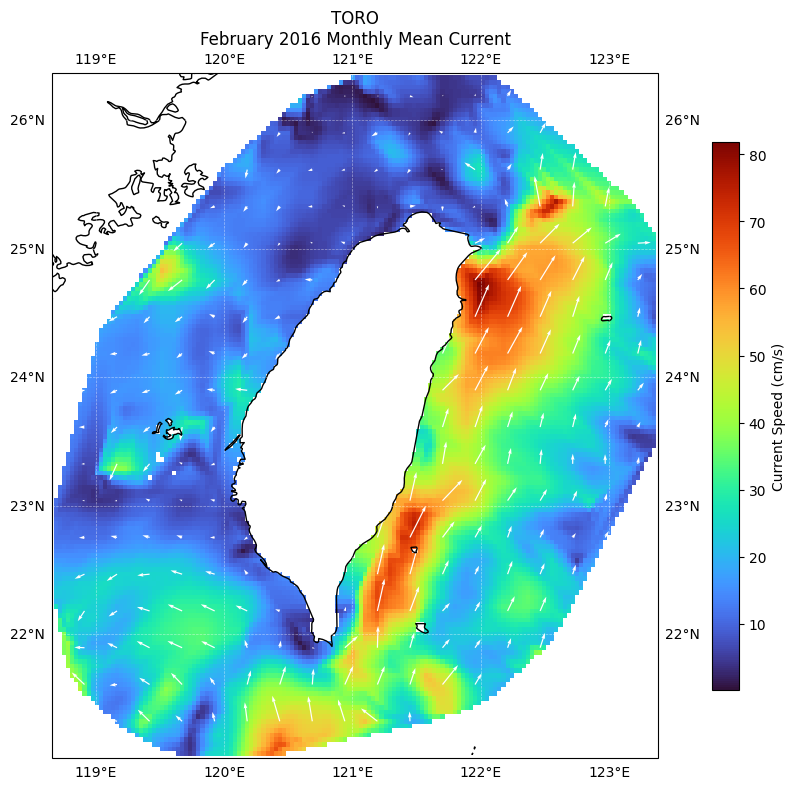

In [34]:
# 月平均海流圖
fig = plt.figure(
    figsize=(11,8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.set_extent(
    [
        lon.min(),
        lon.max(),
        lat.min(),
        lat.max()
    ]
)

ax.coastlines(
    resolution="10m",
    linewidth=1
)

# 底圖
pcm=ax.pcolormesh(
    Lon,
    Lat,
    Speed_grid,
    cmap="turbo",
    shading="auto",
    transform=ccrs.PlateCarree()
)
cbar=plt.colorbar(
    pcm,
    ax=ax,
    shrink=0.8
)

cbar.set_label(
    "Current Speed (cm/s)"
)


# 箭頭
step=8
q=ax.quiver(
    Lon[::step,::step],
    Lat[::step,::step],
    U_grid[::step,::step],
    V_grid[::step,::step],
    color="white",
    scale=1200,
    width=0.002,
    transform=ccrs.PlateCarree()
)

ax.quiverkey(
    q,
    0.85,
    -0.08,
    50,
    "50 cm/s",
    labelpos="E"
)

ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    color="white",
    alpha=0.5
)

plt.title(
    "TORO\nJanuary 2016 Monthly Mean Current",#改標題
    fontsize=12
)

plt.tight_layout()
plt.show()
